In [1]:
import pandas as pd
import optuna
from dotenv import load_dotenv
from strategies_utils import analyze_strategies, get_best_leagues, get_best_strategies

In [2]:
import os
os.chdir("../models/")
from feature_engineering import get_mask, round_to_step, get_return, add_week_column
from etl_pipeline_local import get_win_1_table, get_under_25_table, get_btts_table, get_over_25_table, get_win_2_table, get_x_table
os.chdir("../strategies/")
load_dotenv()

True

In [3]:
strategy_dict = dict()

# 1. BTTS

In [4]:
target_col = "btts"

STUDY_NAME = f"{target_col}_aggregated_study"

study = optuna.load_study(
    study_name=STUDY_NAME,
    storage="sqlite:///../../data/output/optuna_model/aggregated_study.db",
)

print("Totale trial salvati:", len(study.trials))
print("Best assoluto:", study.best_trial.value, study.best_trial.params)

top_trials = sorted(study.trials, key=lambda t: -t.value)

Totale trial salvati: 1
Best assoluto: 1.0466267140358134 {'chance1x2_xg_home_use_min': True, 'chance1x2_xg_home_use_max': True, 'use_chance1x2_xg_home': True, 'chance1x2_xg_home_min': 1.6, 'chance1x2_xg_home_max': 2.3000000000000003, 'chance1x2_xg_away_use_min': True, 'chance1x2_xg_away_use_max': True, 'use_chance1x2_xg_away': False, 'chance1x2_xg_away_min': 1.0, 'chance1x2_xg_away_max': 1.2000000000000002, 'chance1x2_xg_total_use_min': False, 'chance1x2_xg_total_use_max': True, 'use_chance1x2_xg_total': True, 'chance1x2_xg_total_min': 2.4000000000000004, 'chance1x2_xg_total_max': 2.7}


/tmp/ipykernel_22620/4038310933.py:10: UserWarning: The distribution is specified by [0.6000000000000001, 2.4] and step=0.1, but the range is not divisible by `step`. It will be replaced with [0.6000000000000001, 2.3000000000000003].
  print("Totale trial salvati:", len(study.trials))
/tmp/ipykernel_22620/4038310933.py:10: UserWarning: The distribution is specified by [0.6000000000000001, 2.5] and step=0.1, but the range is not divisible by `step`. It will be replaced with [0.6000000000000001, 2.4].
  print("Totale trial salvati:", len(study.trials))
/tmp/ipykernel_22620/4038310933.py:10: UserWarning: The distribution is specified by [1.4000000000000001, 3.6] and step=0.1, but the range is not divisible by `step`. It will be replaced with [1.4000000000000001, 3.5].
  print("Totale trial salvati:", len(study.trials))
/tmp/ipykernel_22620/4038310933.py:10: UserWarning: The distribution is specified by [1.4000000000000001, 3.8000000000000003] and step=0.1, but the range is not divisible b

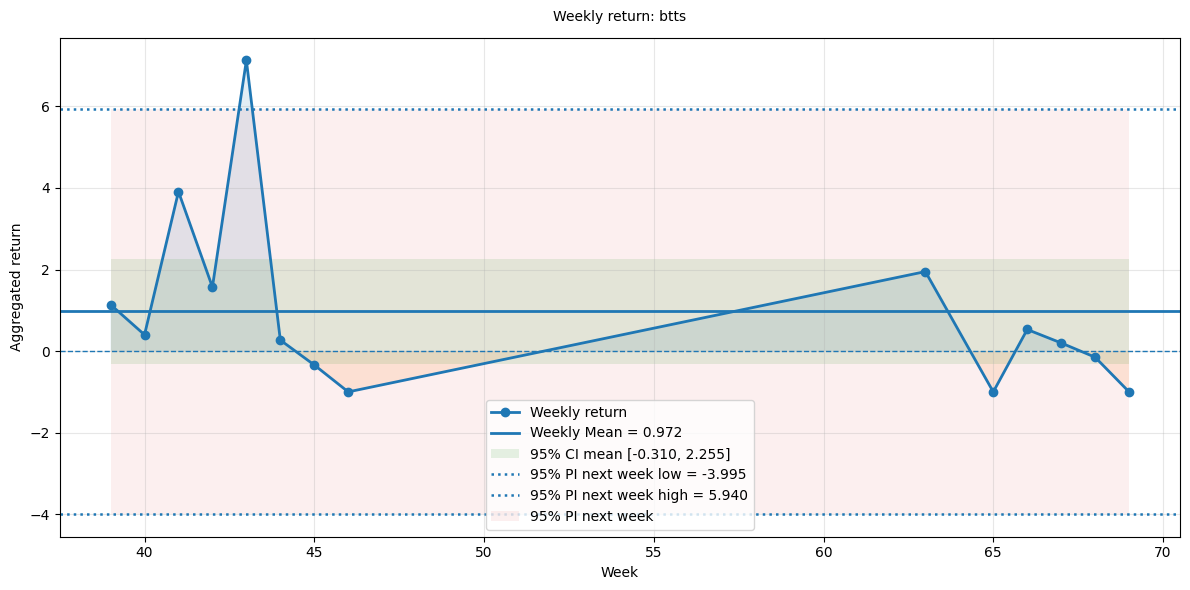

In [5]:
# Choose best trial
best_trial = top_trials[0]
feature_bins_map = best_trial.user_attrs["feature_bins_map"]
params_dict = best_trial.user_attrs["params_dict"]

# Bet setup
target_col = "btts"
odds_col: str = "goalNoGoal_quote_currentGG"

# Load data
df_loaded = get_btts_table()
df_loaded = df_loaded.sort_values('time').reset_index(drop=True)
df = df_loaded.copy()


# Feature Engineering
df["return"] = df.apply(lambda x: get_return(strategy=x[target_col], odds=x[odds_col]), axis=1).copy()
df["week"] = add_week_column(df)
df = df[(df[target_col] >= 1.3) | (df[target_col] <= 2.5)]
# ---

df["strategy"] = target_col


# Create the test binned dataframe
df_binned = df.copy()

for feat, step in feature_bins_map.items():
    df_binned[feat] = [round_to_step(x, step) for x in df_binned[feat]]

    if isinstance(step, int):
        df_binned[feat] = df_binned[feat].astype("Int64")

df_binned = df_binned.sort_values(by="time", ascending=False)

mask = get_mask(df_binned, best_trial.user_attrs["params_dict"])

df_filtered = df_binned[mask]
real_quote = 1. / (df_filtered[target_col].sum() / df_filtered.shape[0])

weekly_return, stats = analyze_strategies(df_filtered, strategies=[target_col], print_pi=True)
strategy_dict[target_col] = {"df_filtered": df_filtered, "real_quote": real_quote, "settings": {"feature_bins_map": feature_bins_map, "params_dict": params_dict}}

In [6]:
get_best_strategies(df_filtered.rename(columns={target_col: "result", "time": "date"}))

,weekly_mean_return,weekly_std_return,weekly_counts,weekly_std_counts,total_counts,accuracy
btts,0.97,2.22,1.84,5.04,127,0.50


# Over 2.5

In [7]:
target_col = "over_25"

STUDY_NAME = f"{target_col}_aggregated_study"

study = optuna.load_study(
    study_name=STUDY_NAME,
    storage="sqlite:///../../data/output/optuna_model/aggregated_study.db",
)

print("Totale trial salvati:", len(study.trials))
print("Best assoluto:", study.best_trial.value, study.best_trial.params)

top_trials = sorted(study.trials, key=lambda t: -t.value)

Totale trial salvati: 1
Best assoluto: 1.51458573919948 {'chance1x2_xg_home_use_min': False, 'chance1x2_xg_home_use_max': True, 'use_chance1x2_xg_home': True, 'chance1x2_xg_home_min': 0.7000000000000001, 'chance1x2_xg_home_max': 1.4000000000000001, 'chance1x2_xg_away_use_min': True, 'chance1x2_xg_away_use_max': False, 'use_chance1x2_xg_away': False, 'chance1x2_xg_away_min': 1.7000000000000002, 'chance1x2_xg_away_max': 1.9000000000000001, 'chance1x2_xg_total_use_min': True, 'chance1x2_xg_total_use_max': True, 'use_chance1x2_xg_total': True, 'chance1x2_xg_total_min': 2.2, 'chance1x2_xg_total_max': 2.4000000000000004}


/tmp/ipykernel_22620/2623453569.py:10: UserWarning: The distribution is specified by [0.6000000000000001, 2.4] and step=0.1, but the range is not divisible by `step`. It will be replaced with [0.6000000000000001, 2.3000000000000003].
  print("Totale trial salvati:", len(study.trials))
/tmp/ipykernel_22620/2623453569.py:10: UserWarning: The distribution is specified by [0.6000000000000001, 2.5] and step=0.1, but the range is not divisible by `step`. It will be replaced with [0.6000000000000001, 2.4].
  print("Totale trial salvati:", len(study.trials))
/tmp/ipykernel_22620/2623453569.py:10: UserWarning: The distribution is specified by [1.4000000000000001, 3.6] and step=0.1, but the range is not divisible by `step`. It will be replaced with [1.4000000000000001, 3.5].
  print("Totale trial salvati:", len(study.trials))
/tmp/ipykernel_22620/2623453569.py:10: UserWarning: The distribution is specified by [1.4000000000000001, 3.8000000000000003] and step=0.1, but the range is not divisible b

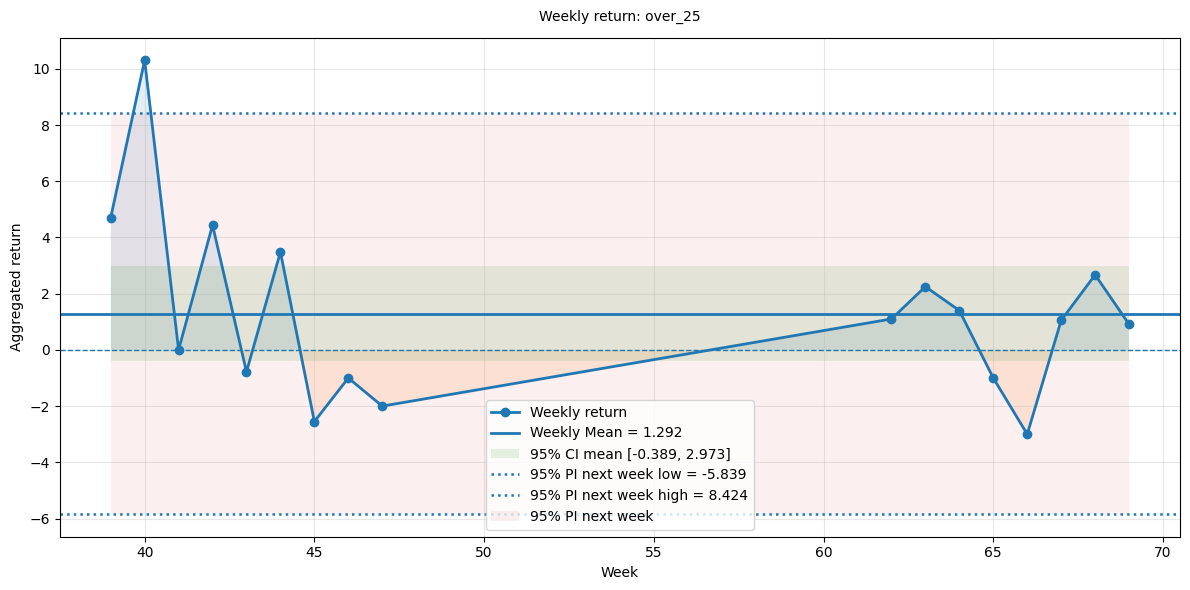

In [8]:
# Choose best trial
best_trial = top_trials[0]
feature_bins_map = best_trial.user_attrs["feature_bins_map"]
params_dict = best_trial.user_attrs["params_dict"]

# Bet setup
target_col = "over_25"
odds_col: str = "underOver_quote_currentO"

# Load data
df_loaded = get_over_25_table()
df_loaded = df_loaded.sort_values('time').reset_index(drop=True)
df = df_loaded.copy()


# Feature Engineering
df["return"] = df.apply(lambda x: get_return(strategy=x[target_col], odds=x[odds_col]), axis=1).copy()
df["week"] = add_week_column(df)
df = df[(df[target_col] >= 1.3) | (df[target_col] <= 2.5)]
# ---

df["strategy"] = target_col


# Create the test binned dataframe
df_binned = df.copy()

for feat, step in feature_bins_map.items():
    df_binned[feat] = [round_to_step(x, step) for x in df_binned[feat]]

    if isinstance(step, int):
        df_binned[feat] = df_binned[feat].astype("Int64")

df_binned = df_binned.sort_values(by="time", ascending=False)

mask = get_mask(df_binned, best_trial.user_attrs["params_dict"])

df_filtered = df_binned[mask]
real_quote = 1. / (df_filtered[target_col].sum() / df_filtered.shape[0])

weekly_return, stats = analyze_strategies(df_filtered, strategies=[target_col], print_pi=True)
strategy_dict[target_col] = {"df_filtered": df_filtered, "real_quote": real_quote, "settings": {"feature_bins_map": feature_bins_map, "params_dict": params_dict}}

In [9]:
get_best_strategies(df_filtered.rename(columns={target_col: "result", "time": "date"}))

,weekly_mean_return,weekly_std_return,weekly_counts,weekly_std_counts,total_counts,accuracy
over_25,1.29,3.27,3.07,7.82,212,0.46


# Under 2.5

In [10]:
target_col = "under_25"

STUDY_NAME = f"{target_col}_aggregated_study"

study = optuna.load_study(
    study_name=STUDY_NAME,
    storage="sqlite:///../../data/output/optuna_model/aggregated_study.db",
)

print("Totale trial salvati:", len(study.trials))
print("Best assoluto:", study.best_trial.value, study.best_trial.params)

top_trials = sorted(study.trials, key=lambda t: -t.value)

Totale trial salvati: 1
Best assoluto: -0.6228300839097514 {'chance1x2_xg_home_use_min': True, 'chance1x2_xg_home_use_max': True, 'use_chance1x2_xg_home': True, 'chance1x2_xg_home_min': 1.6, 'chance1x2_xg_home_max': 1.7000000000000002, 'chance1x2_xg_away_use_min': True, 'chance1x2_xg_away_use_max': True, 'use_chance1x2_xg_away': True, 'chance1x2_xg_away_min': 1.3, 'chance1x2_xg_away_max': 1.6, 'chance1x2_xg_total_use_min': True, 'chance1x2_xg_total_use_max': True, 'use_chance1x2_xg_total': False, 'chance1x2_xg_total_min': 2.6000000000000005, 'chance1x2_xg_total_max': 3.3000000000000003}


/tmp/ipykernel_22620/536828116.py:10: UserWarning: The distribution is specified by [0.6000000000000001, 2.4] and step=0.1, but the range is not divisible by `step`. It will be replaced with [0.6000000000000001, 2.3000000000000003].
  print("Totale trial salvati:", len(study.trials))
/tmp/ipykernel_22620/536828116.py:10: UserWarning: The distribution is specified by [0.6000000000000001, 2.5] and step=0.1, but the range is not divisible by `step`. It will be replaced with [0.6000000000000001, 2.4].
  print("Totale trial salvati:", len(study.trials))
/tmp/ipykernel_22620/536828116.py:10: UserWarning: The distribution is specified by [1.4000000000000001, 3.6] and step=0.1, but the range is not divisible by `step`. It will be replaced with [1.4000000000000001, 3.5].
  print("Totale trial salvati:", len(study.trials))
/tmp/ipykernel_22620/536828116.py:10: UserWarning: The distribution is specified by [1.4000000000000001, 3.8000000000000003] and step=0.1, but the range is not divisible by `s

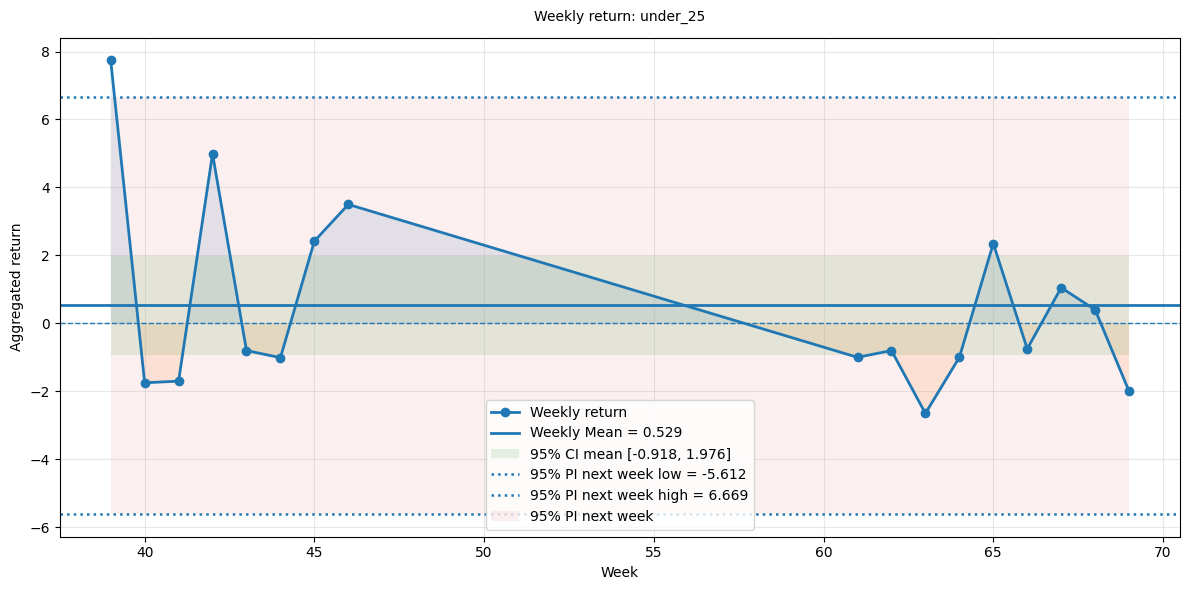

In [11]:
# Choose best trial
best_trial = top_trials[0]
feature_bins_map = best_trial.user_attrs["feature_bins_map"]
params_dict = best_trial.user_attrs["params_dict"]

# Bet setup
target_col = "under_25"
odds_col: str = "underOver_quote_currentU"

# Load data
df_loaded = get_under_25_table()
df_loaded = df_loaded.sort_values('time').reset_index(drop=True)
df = df_loaded.copy()


# Feature Engineering
df["return"] = df.apply(lambda x: get_return(strategy=x[target_col], odds=x[odds_col]), axis=1).copy()
df["week"] = add_week_column(df)
df = df[(df[target_col] >= 1.3) | (df[target_col] <= 2.5)]
# ---

df["strategy"] = target_col


# Create the test binned dataframe
df_binned = df.copy()

for feat, step in feature_bins_map.items():
    df_binned[feat] = [round_to_step(x, step) for x in df_binned[feat]]

    if isinstance(step, int):
        df_binned[feat] = df_binned[feat].astype("Int64")

df_binned = df_binned.sort_values(by="time", ascending=False)

mask = get_mask(df_binned, best_trial.user_attrs["params_dict"])

df_filtered = df_binned[mask]
real_quote = 1. / (df_filtered[target_col].sum() / df_filtered.shape[0])

weekly_return, stats = analyze_strategies(df_filtered, strategies=[target_col], print_pi=True)
strategy_dict[target_col] = {"df_filtered": df_filtered, "real_quote": real_quote, "settings": {"feature_bins_map": feature_bins_map, "params_dict": params_dict}}

In [12]:
get_best_strategies(df_filtered.rename(columns={target_col: "result", "time": "date"}))

,weekly_mean_return,weekly_std_return,weekly_counts,weekly_std_counts,total_counts,accuracy
under_25,0.53,2.81,2.12,5.42,146,0.46


# Win 1

In [13]:
target_col = "win_1"

STUDY_NAME = f"{target_col}_aggregated_study"

study = optuna.load_study(
    study_name=STUDY_NAME,
    storage="sqlite:///../../data/output/optuna_model/aggregated_study.db",
)

print("Totale trial salvati:", len(study.trials))
print("Best assoluto:", study.best_trial.value, study.best_trial.params)

top_trials = sorted(study.trials, key=lambda t: -t.value)

Totale trial salvati: 1
Best assoluto: -0.6712293986781479 {'chance1x2_xg_home_use_min': True, 'chance1x2_xg_home_use_max': True, 'use_chance1x2_xg_home': False, 'chance1x2_xg_home_min': 0.9000000000000001, 'chance1x2_xg_home_max': 2.2, 'chance1x2_xg_away_use_min': True, 'chance1x2_xg_away_use_max': False, 'use_chance1x2_xg_away': True, 'chance1x2_xg_away_min': 1.2000000000000002, 'chance1x2_xg_away_max': 1.4, 'chance1x2_xg_total_use_min': True, 'chance1x2_xg_total_use_max': True, 'use_chance1x2_xg_total': True, 'chance1x2_xg_total_min': 2.6000000000000005, 'chance1x2_xg_total_max': 2.7}


/tmp/ipykernel_22620/2995726167.py:10: UserWarning: The distribution is specified by [0.6000000000000001, 2.4] and step=0.1, but the range is not divisible by `step`. It will be replaced with [0.6000000000000001, 2.3000000000000003].
  print("Totale trial salvati:", len(study.trials))
/tmp/ipykernel_22620/2995726167.py:10: UserWarning: The distribution is specified by [0.6000000000000001, 2.5] and step=0.1, but the range is not divisible by `step`. It will be replaced with [0.6000000000000001, 2.4].
  print("Totale trial salvati:", len(study.trials))
/tmp/ipykernel_22620/2995726167.py:10: UserWarning: The distribution is specified by [1.4000000000000001, 3.6] and step=0.1, but the range is not divisible by `step`. It will be replaced with [1.4000000000000001, 3.5].
  print("Totale trial salvati:", len(study.trials))
/tmp/ipykernel_22620/2995726167.py:10: UserWarning: The distribution is specified by [1.4000000000000001, 3.8000000000000003] and step=0.1, but the range is not divisible b

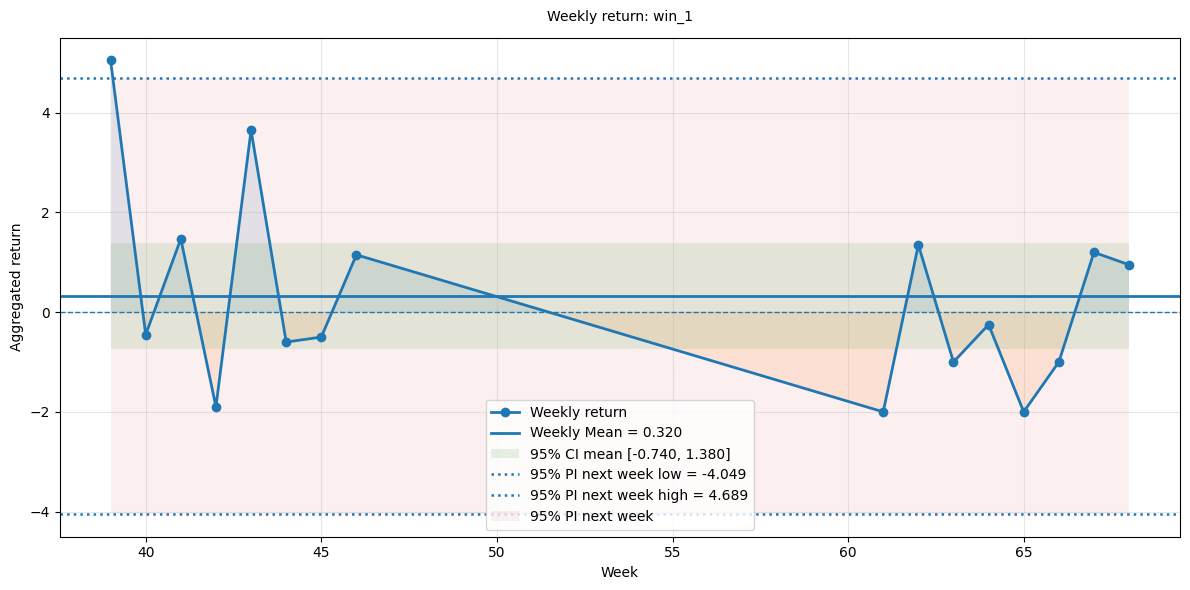

In [14]:
# Choose best trial
best_trial = top_trials[0]
feature_bins_map = best_trial.user_attrs["feature_bins_map"]
params_dict = best_trial.user_attrs["params_dict"]

# Bet setup
target_col = "win_1"
odds_col: str = "chance1x2_quote_current1"

# Load data
df_loaded = get_win_1_table()
df_loaded = df_loaded.sort_values('time').reset_index(drop=True)
df = df_loaded.copy()


# Feature Engineering
df["return"] = df.apply(lambda x: get_return(strategy=x[target_col], odds=x[odds_col]), axis=1).copy()
df["week"] = add_week_column(df)
df = df[(df[target_col] >= 1.3) | (df[target_col] <= 2.5)]
# ---

df["strategy"] = target_col


# Create the test binned dataframe
df_binned = df.copy()

for feat, step in feature_bins_map.items():
    df_binned[feat] = [round_to_step(x, step) for x in df_binned[feat]]

    if isinstance(step, int):
        df_binned[feat] = df_binned[feat].astype("Int64")

df_binned = df_binned.sort_values(by="time", ascending=False)

mask = get_mask(df_binned, best_trial.user_attrs["params_dict"])

df_filtered = df_binned[mask]
real_quote = 1. / (df_filtered[target_col].sum() / df_filtered.shape[0])

weekly_return, stats = analyze_strategies(df_filtered, strategies=[target_col], print_pi=True)
strategy_dict[target_col] = {"df_filtered": df_filtered, "real_quote": real_quote, "settings": {"feature_bins_map": feature_bins_map, "params_dict": params_dict}}

In [15]:
get_best_strategies(df_filtered.rename(columns={target_col: "result", "time": "date"}))

,weekly_mean_return,weekly_std_return,weekly_counts,weekly_std_counts,total_counts,accuracy
win_1,0.32,1.99,2.37,6.47,161,0.42


# Win 2

In [16]:
target_col = "win_2"

STUDY_NAME = f"{target_col}_aggregated_study"

study = optuna.load_study(
    study_name=STUDY_NAME,
    storage="sqlite:///../../data/output/optuna_model/aggregated_study.db",
)

print("Totale trial salvati:", len(study.trials))
print("Best assoluto:", study.best_trial.value, study.best_trial.params)

top_trials = sorted(study.trials, key=lambda t: -t.value)

Totale trial salvati: 1
Best assoluto: 2.8991407958141684 {'chance1x2_xg_home_use_min': False, 'chance1x2_xg_home_use_max': True, 'use_chance1x2_xg_home': False, 'chance1x2_xg_home_min': 1.5, 'chance1x2_xg_home_max': 1.7000000000000002, 'chance1x2_xg_away_use_min': True, 'chance1x2_xg_away_use_max': False, 'use_chance1x2_xg_away': True, 'chance1x2_xg_away_min': 1.6, 'chance1x2_xg_away_max': 2.3, 'chance1x2_xg_total_use_min': False, 'chance1x2_xg_total_use_max': True, 'use_chance1x2_xg_total': True, 'chance1x2_xg_total_min': 2.6000000000000005, 'chance1x2_xg_total_max': 3.2}


/tmp/ipykernel_22620/3755587584.py:10: UserWarning: The distribution is specified by [0.6000000000000001, 2.4] and step=0.1, but the range is not divisible by `step`. It will be replaced with [0.6000000000000001, 2.3000000000000003].
  print("Totale trial salvati:", len(study.trials))
/tmp/ipykernel_22620/3755587584.py:10: UserWarning: The distribution is specified by [0.6000000000000001, 2.5] and step=0.1, but the range is not divisible by `step`. It will be replaced with [0.6000000000000001, 2.4].
  print("Totale trial salvati:", len(study.trials))
/tmp/ipykernel_22620/3755587584.py:10: UserWarning: The distribution is specified by [1.4000000000000001, 3.6] and step=0.1, but the range is not divisible by `step`. It will be replaced with [1.4000000000000001, 3.5].
  print("Totale trial salvati:", len(study.trials))
/tmp/ipykernel_22620/3755587584.py:10: UserWarning: The distribution is specified by [1.4000000000000001, 3.8000000000000003] and step=0.1, but the range is not divisible b

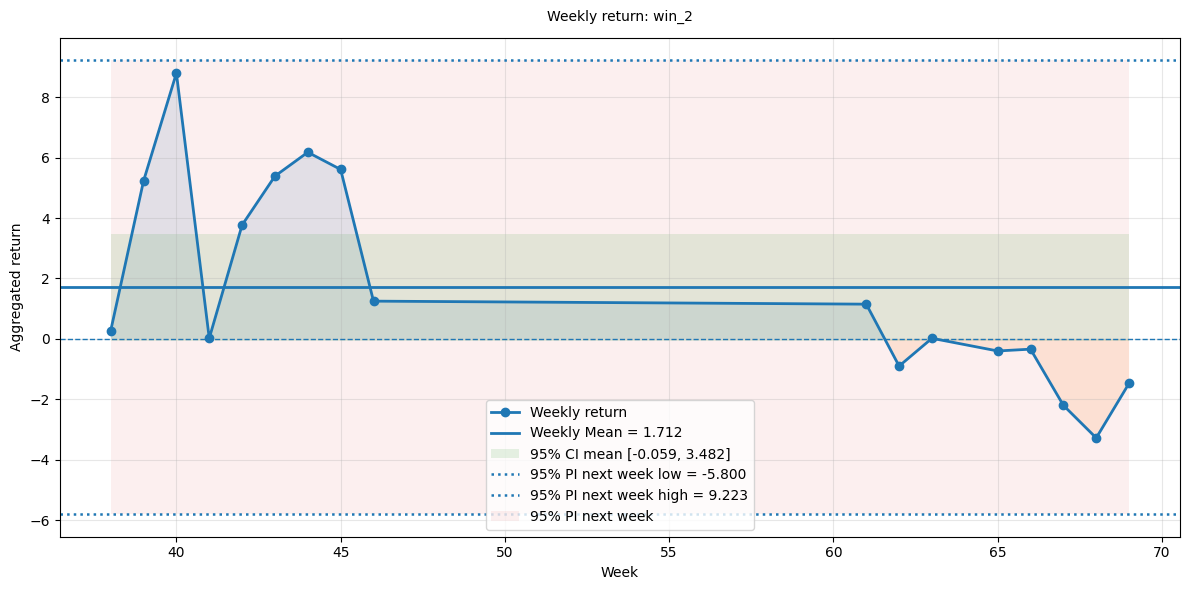

In [17]:
# Choose best trial
best_trial = top_trials[0]
feature_bins_map = best_trial.user_attrs["feature_bins_map"]
params_dict = best_trial.user_attrs["params_dict"]

# Bet setup
target_col = "win_2"
odds_col: str = "chance1x2_quote_current2"

# Load data
df_loaded = get_win_2_table()
df_loaded = df_loaded.sort_values('time').reset_index(drop=True)
df = df_loaded.copy()


# Feature Engineering
df["return"] = df.apply(lambda x: get_return(strategy=x[target_col], odds=x[odds_col]), axis=1).copy()
df["week"] = add_week_column(df)
df = df[(df[target_col] >= 1.3) | (df[target_col] <= 2.5)]
# ---

df["strategy"] = target_col


# Create the test binned dataframe
df_binned = df.copy()

for feat, step in feature_bins_map.items():
    df_binned[feat] = [round_to_step(x, step) for x in df_binned[feat]]

    if isinstance(step, int):
        df_binned[feat] = df_binned[feat].astype("Int64")

df_binned = df_binned.sort_values(by="time", ascending=False)

mask = get_mask(df_binned, best_trial.user_attrs["params_dict"])

df_filtered = df_binned[mask]
real_quote = 1. / (df_filtered[target_col].sum() / df_filtered.shape[0])

weekly_return, stats = analyze_strategies(df_filtered, strategies=[target_col], print_pi=True)
strategy_dict[target_col] = {"df_filtered": df_filtered, "real_quote": real_quote, "settings": {"feature_bins_map": feature_bins_map, "params_dict": params_dict}}

In [18]:
get_best_strategies(df_filtered.rename(columns={target_col: "result", "time": "date"}))

,weekly_mean_return,weekly_std_return,weekly_counts,weekly_std_counts,total_counts,accuracy
win_2,1.71,3.44,3.72,10.04,257,0.58


# Tie

In [24]:
target_col = "tie"

STUDY_NAME = f"{target_col}_aggregated_study"

study = optuna.load_study(
    study_name=STUDY_NAME,
    storage="sqlite:///../../data/output/optuna_model/aggregated_study.db",
)

print("Totale trial salvati:", len(study.trials))
print("Best assoluto:", study.best_trial.value, study.best_trial.params)

top_trials = sorted(study.trials, key=lambda t: -t.value)

Totale trial salvati: 1
Best assoluto: 2.983052691223313 {'chance1x2_xg_home_use_min': True, 'chance1x2_xg_home_use_max': False, 'use_chance1x2_xg_home': True, 'chance1x2_xg_home_min': 1.2000000000000002, 'chance1x2_xg_home_max': 2.2, 'chance1x2_xg_away_use_min': True, 'chance1x2_xg_away_use_max': True, 'use_chance1x2_xg_away': True, 'chance1x2_xg_away_min': 1.7000000000000002, 'chance1x2_xg_away_max': 2.2, 'chance1x2_xg_total_use_min': False, 'chance1x2_xg_total_use_max': True, 'use_chance1x2_xg_total': True, 'chance1x2_xg_total_min': 3.6, 'chance1x2_xg_total_max': 3.6000000000000005}


/tmp/ipykernel_22620/3079384204.py:10: UserWarning: The distribution is specified by [0.6000000000000001, 2.4] and step=0.1, but the range is not divisible by `step`. It will be replaced with [0.6000000000000001, 2.3000000000000003].
  print("Totale trial salvati:", len(study.trials))
/tmp/ipykernel_22620/3079384204.py:10: UserWarning: The distribution is specified by [0.6000000000000001, 2.5] and step=0.1, but the range is not divisible by `step`. It will be replaced with [0.6000000000000001, 2.4].
  print("Totale trial salvati:", len(study.trials))
/tmp/ipykernel_22620/3079384204.py:10: UserWarning: The distribution is specified by [1.4000000000000001, 3.6] and step=0.1, but the range is not divisible by `step`. It will be replaced with [1.4000000000000001, 3.5].
  print("Totale trial salvati:", len(study.trials))
/tmp/ipykernel_22620/3079384204.py:10: UserWarning: The distribution is specified by [1.4000000000000001, 3.8000000000000003] and step=0.1, but the range is not divisible b

In [25]:
df_loaded[df_loaded['chance1x2_xg_home'].notna()].tail()

,time,chance1x2_chance_p1,chance1x2_chance_px,chance1x2_chance_p2,chance1x2_chance_p1x,chance1x2_chance_p2x,chance1x2_chance_p12,chance1x2_chance_pHt1,chance1x2_chance_pHtx,chance1x2_chance_pHt2,...,underOver_flashback_under35,underOver_flashback_over35,chance1x2_xg_home,chance1x2_xg_away,chance1x2_xg_total,chance1x2_xg,team_corner,team_goal,team_goalHt,win_2
16005,2026-09-02 20:45:00,37.60,32.60,29.80,70.20,62.40,67.40,30.20,46.40,23.40,...,75.50,24.50,1.29,0.75,NaN,NaN,NaN,NaN,NaN,False
16006,2026-09-02 20:45:00,22.80,26.10,51.10,48.90,77.20,73.90,15.60,33.10,51.30,...,63.10,36.90,1.01,3.07,NaN,NaN,NaN,NaN,NaN,True
16010,2026-09-02 21:00:00,13.90,27.80,58.30,41.70,86.10,72.20,22.20,35.10,42.70,...,65.40,34.60,0.71,1.63,2.29,NaN,NaN,NaN,NaN,True
16012,2026-09-02 21:00:00,22.60,29.00,48.40,51.60,77.40,71.00,22.10,41.00,36.90,...,63.10,36.90,1.60,1.98,NaN,NaN,NaN,NaN,NaN,False
16016,2026-09-03 00:30:00,74.20,18.50,7.30,92.70,25.80,81.50,56.70,32.70,10.60,...,59.00,41.00,1.71,1.02,2.70,NaN,NaN,NaN,NaN,False


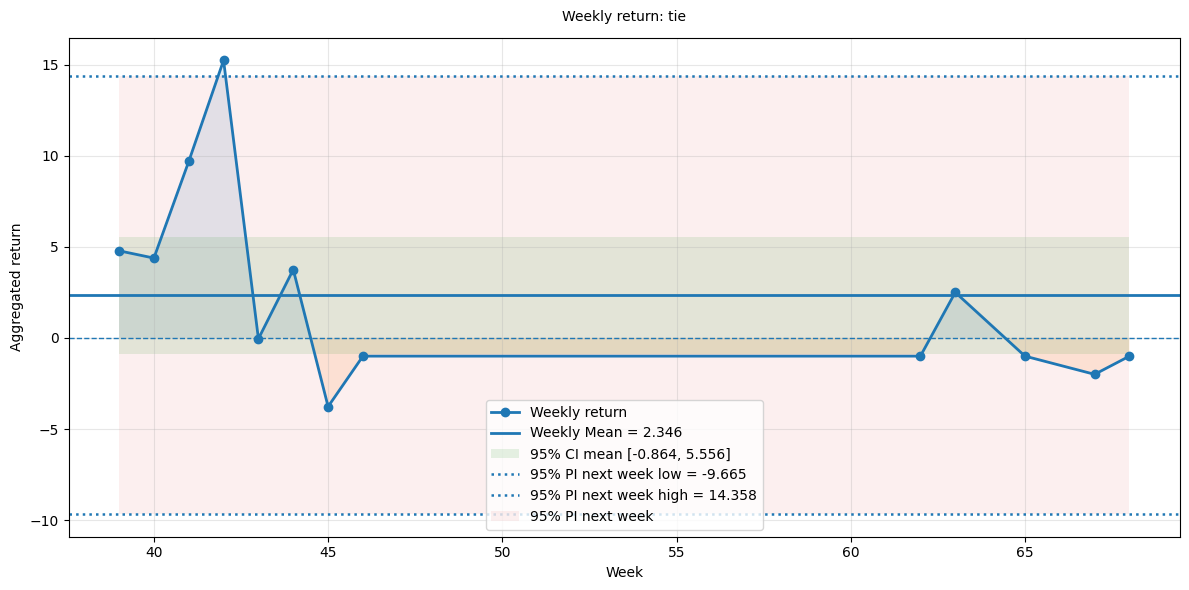

In [26]:
# Choose best trial
best_trial = top_trials[0]
feature_bins_map = best_trial.user_attrs["feature_bins_map"]
params_dict = best_trial.user_attrs["params_dict"]

# Bet setup
target_col = "tie"
odds_col: str = "chance1x2_quote_currentx"

# Load data
df_loaded = get_x_table()
df_loaded = df_loaded.sort_values('time').reset_index(drop=True)
df = df_loaded.copy()


# Feature Engineering
df["return"] = df.apply(lambda x: get_return(strategy=x[target_col], odds=x[odds_col]), axis=1).copy()
df["week"] = add_week_column(df)
df = df[(df[target_col] >= 1.3) | (df[target_col] <= 2.5)]
# ---

df["strategy"] = target_col


# Create the test binned dataframe
df_binned = df.copy()

for feat, step in feature_bins_map.items():
    df_binned[feat] = [round_to_step(x, step) for x in df_binned[feat]]

    if isinstance(step, int):
        df_binned[feat] = df_binned[feat].astype("Int64")

df_binned = df_binned.sort_values(by="time", ascending=False)

mask = get_mask(df_binned, best_trial.user_attrs["params_dict"])

df_filtered = df_binned[mask]
real_quote = 1. / (df_filtered[target_col].sum() / df_filtered.shape[0])

weekly_return, stats = analyze_strategies(df_filtered, strategies=[target_col], print_pi=True)
strategy_dict[target_col] = {"df_filtered": df_filtered, "real_quote": real_quote, "settings": {"feature_bins_map": feature_bins_map, "params_dict": params_dict}}

In [27]:
get_best_strategies(df_filtered.rename(columns={target_col: "result", "time": "date"}))

,weekly_mean_return,weekly_std_return,weekly_counts,weekly_std_counts,total_counts,accuracy
tie,2.35,5.31,1.85,5.19,126,0.21


# Forecast

In [24]:
strategy_dict.keys()

dict_keys(['btts', 'over_25', 'under_25', 'win_1', 'win_2', 'tie'])

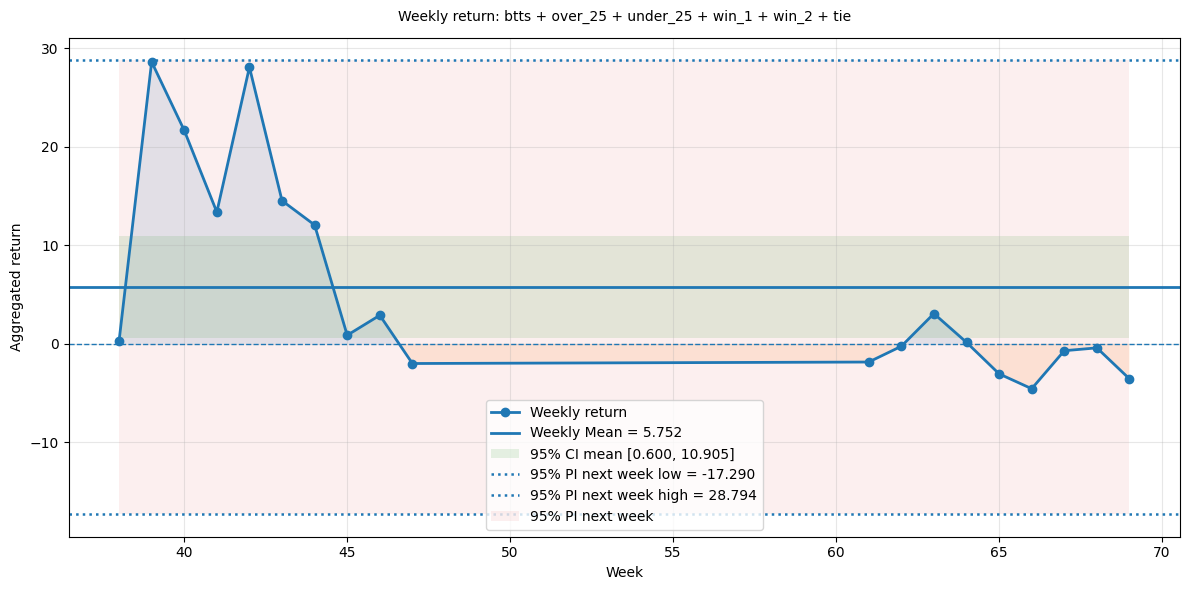

In [28]:
strategies = ['btts', 'over_25', 'under_25', 'win_1', 'win_2', 'tie'] # strategy_dict.keys()

for i, key in enumerate(strategy_dict.keys()):
    if i == 0:
        df_final = strategy_dict[key]['df_filtered']
    else:
        df_item = strategy_dict[key]['df_filtered']
        df_final = pd.concat([df_final, df_item], axis=0)

df_final = df_final.reset_index(drop=True)

weekly_return, stats = analyze_strategies(df_final, strategies=strategies, print_pi=True)

In [30]:
df_final = df_final.rename(columns={"team_league": "league"})

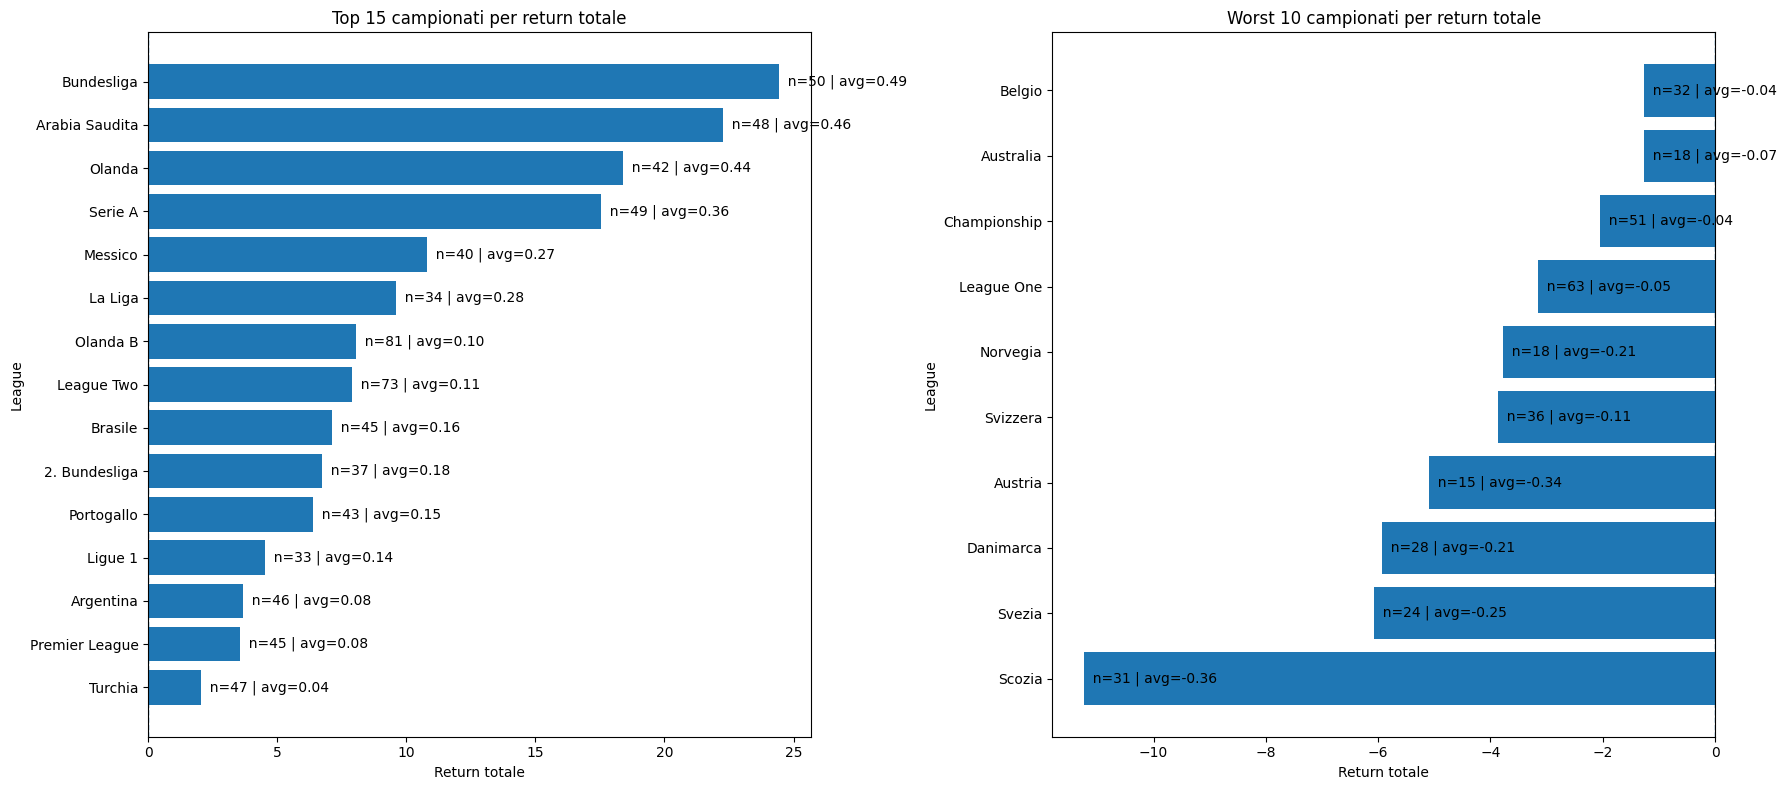

In [31]:
top_leagues = get_best_leagues(df_final, strategies=strategy_dict.keys())

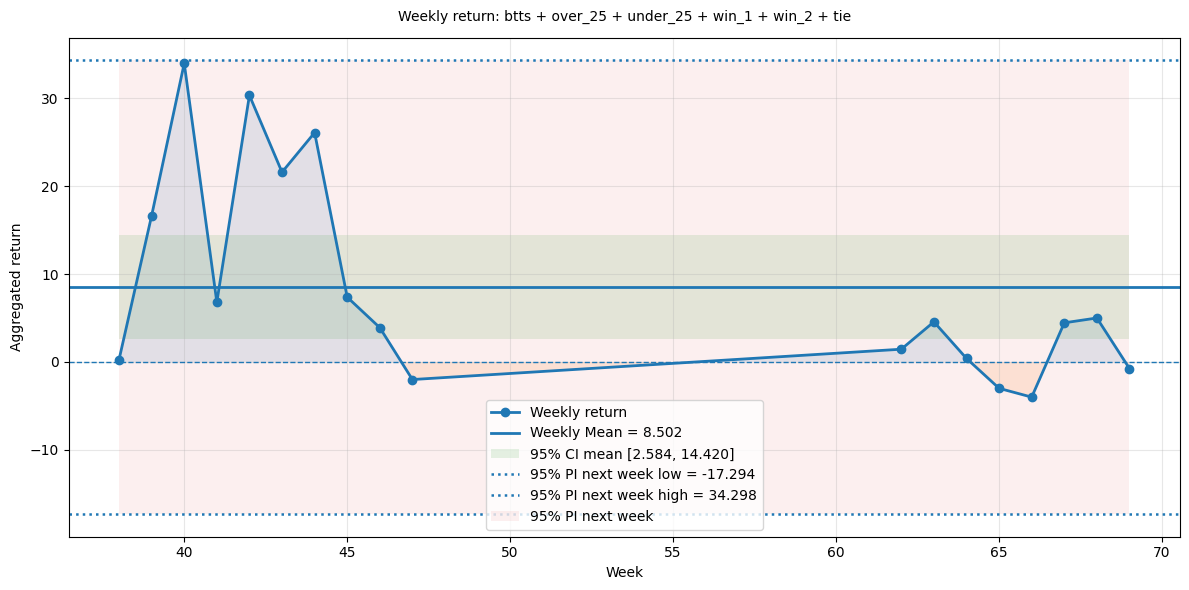

In [32]:
weekly_return, stats = analyze_strategies(df_final, strategies=strategies, leagues=top_leagues.index.to_list(),print_pi=True)

In [34]:
output_dict = dict()

for strategy in strategies:
    output_dict[strategy]= strategy_dict[strategy]['settings']
 
output_dict["top_leagues"] = top_leagues.index.to_list()

In [35]:
import json 
with open("strategies.json", "w", encoding="utf-8") as f:
    json.dump(output_dict, f, indent=2)